In [5]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Este notebook se trabajo utilizando Kaggle en una configuración multi gpu, para probar que si servía puse
# algunos prints como verificación que si funcionaban ambas gpus T4
strategy = tf.distribute.MirroredStrategy()
print(f"GPUs disponibles: {strategy.num_replicas_in_sync}")

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
GPUs disponibles: 2


In [6]:
DATA_DIR = '/kaggle/input/datasets/aryashah2k/mango-leaf-disease-dataset'
BATCH_SIZE = 32 * strategy.num_replicas_in_sync
IMG_SIZE = (224, 224)

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
])

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(
    lambda x, y: (tf.keras.applications.vgg16.preprocess_input(x), y), 
    num_parallel_calls=AUTOTUNE
)
val_ds = val_ds.map(
    lambda x, y: (tf.keras.applications.vgg16.preprocess_input(x), y), 
    num_parallel_calls=AUTOTUNE
)

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 4000 files belonging to 8 classes.
Using 3200 files for training.
Found 4000 files belonging to 8 classes.
Using 800 files for validation.


In [7]:
# este scope me permite, con la configuración que se declaro en el primer chunk 
# "strategy = tf.distribute.MirroredStrategy()" dividir los datos en las 2 gpus, pero
# unifica el aprendizaje
with strategy.scope():
    base_model = tf.keras.applications.VGG16(
        input_shape=IMG_SIZE + (3,),
        include_top=False,
        weights='imagenet'
    )
    
    base_model.trainable = False
    
    inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
    x = data_augmentation(inputs)
    x = base_model(x, training=False)
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')(x)
    
    model = tf.keras.Model(inputs, outputs)
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

In [8]:
# training y backpropagation
EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Redu

I0000 00:00:1772729981.611926     119 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1772729981.890031     121 cuda_dnn.cc:529] Loaded cuDNN version 91002


50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.6716 - loss: 4.8973INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
50/50 ━━━━━━━━━━━━━━━━━━━━ 27s 341ms/step - accuracy: 0.6744 - loss: 4.8464 - val_accuracy: 0.9588 - val_loss: 0.1792
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 301ms/step - accuracy: 0.9174 - loss: 0.4645 - val_accuracy: 0.9762 - val_loss: 0.0721
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 310ms/step - accuracy: 0.9398 - loss: 0.2549 - val_accuracy: 0.9812 - val_loss: 0.0593
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 322ms/step - accuracy: 0.9484 - loss: 0.2461 - val_accuracy: 0.9887 - val_loss: 0.0509
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 316ms/step - accuracy: 0.9456 - loss: 0.2325 - val_accuracy: 0.9912 - val_loss: 0.0317
Epoch 6/10
5

13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 235ms/step - accuracy: 0.9858 - loss: 0.0593
Accuracy global: 0.9875


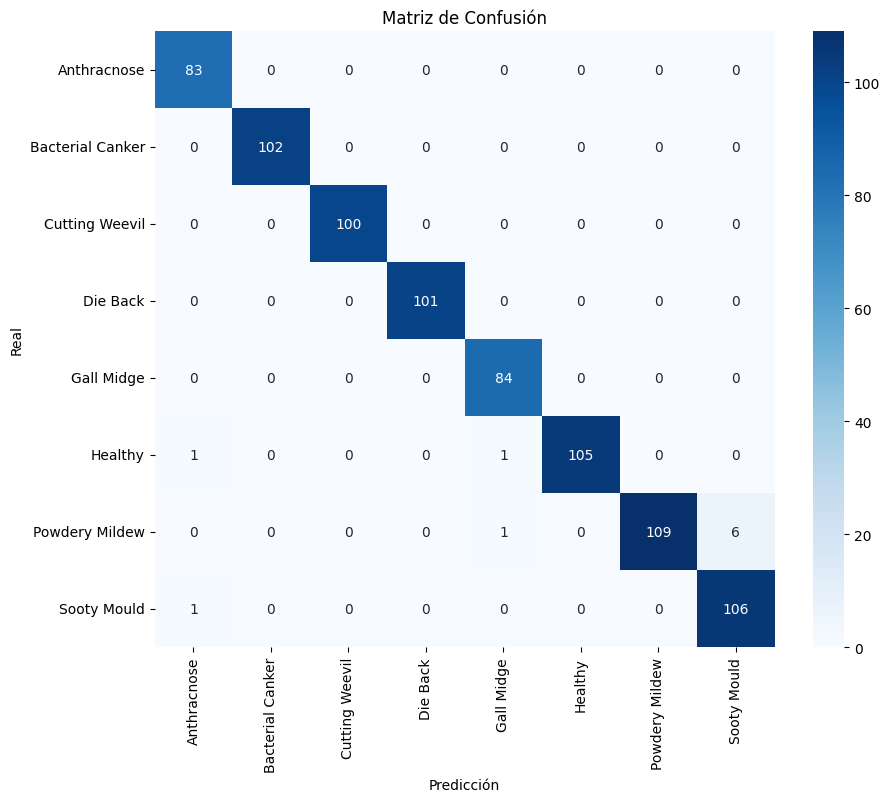

In [9]:
# evaluaci'on del modelo
val_loss, val_acc = model.evaluate(val_ds)
print(f"Accuracy global: {val_acc:.4f}")

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()